## DATA CLEANING

In [ ]:
import pandas as pd

## **SHEET 1**

Steps 1 : Kenalan dengan Sheets — Kenali Anomali nya


In [ ]:
# Baca sheet pertama
df = pd.read_excel("data_latihan_bi_kotor.xlsx", sheet_name="Transaksi_BI")

In [ ]:
print(df.head(10).to_string())

      Tanggal Kode_Transaksi           Kantor_BI Kanal_Pembayaran Jenis_Transaksi     Kategori Nilai_Transaksi  Biaya_Admin
0  2024-03-01      TRX000001   KPwBI DKI Jakarta             QRIS      Pemerintah   Penerimaan      -582831000       2500.0
1  2024-10-20      TRX000002          KPwBI Bali            Tunai        Individu  Pengeluaran     657.755.000          0.0
2  2024-01-02      TRX000003   KPwBI DKI Jakarta      Kartu Debit        Individu  Pengeluaran             NaN       2500.0
3  2024-12-16      TRX000004          KPwBI Bali            Tunai       Korporasi   Penerimaan      -283496000          0.0
4  01/07/2024      TRX000005  KPwBI DKI Jakarta      Kartu Kredit       Korporasi   Penerimaan       651078000       5000.0
5  2024-08-22      TRX000006   KPwBI Jawa Timur              QRIS       Korporasi  Pengeluaran       633874000       2500.0
6  29/12/2024      TRX000007   KPwBI DKI Jakarta            tunai        Individu   Penerimaan       415504000          0.0
7  29/02

In [ ]:
# Lihat tipe data setiap kolom
print(df.dtypes)

Tanggal              object
Kode_Transaksi       object
Kantor_BI            object
Kanal_Pembayaran     object
Jenis_Transaksi      object
Kategori             object
Nilai_Transaksi      object
Biaya_Admin         float64
dtype: object


In [ ]:
# Lihat missing value setiap kolom
print(df.isnull().sum())

Tanggal             0
Kode_Transaksi      0
Kantor_BI           4
Kanal_Pembayaran    4
Jenis_Transaksi     3
Kategori            2
Nilai_Transaksi     5
Biaya_Admin         6
dtype: int64


In [ ]:
df.columns

Index(['Tanggal', 'Kode_Transaksi', 'Kantor_BI', 'Kanal_Pembayaran',
       'Jenis_Transaksi', 'Kategori', 'Nilai_Transaksi', 'Biaya_Admin'],
      dtype='object')

In [ ]:
# Lihat unique value setiap kolom
for nama_kolom in ['Tanggal', 'Kode_Transaksi', 'Kantor_BI', 'Kanal_Pembayaran',
       'Jenis_Transaksi', 'Kategori', 'Nilai_Transaksi', 'Biaya_Admin']:
  print(nama_kolom, ":->", list(df[nama_kolom].unique()))
  print()

Tanggal :-> ['2024-03-01', '2024-10-20', '2024-01-02', '2024-12-16', '01/07/2024', '2024-08-22', '29/12/2024', '29/02/2024', '2024-09-25', '2024-03-07', '03/09/2024', '2024-12-31', '2024-12-08', '09/08/2024', '03/07/2024', '2024-08-10', '20/02/2024', '2024-04-03', '2024-09-12', '08/01/2024', datetime.datetime(2024, 3, 2, 0, 0), '2024-01-03', '30 August 2024', '27/10/2024', '2024-11-26', datetime.datetime(2024, 6, 16, 0, 0), '19/10/2024', datetime.datetime(2024, 11, 15, 0, 0), '2024-01-18', datetime.datetime(2024, 11, 24, 0, 0), '21/09/2024', '2024-05-19', datetime.datetime(2024, 4, 5, 0, 0), '27 August 2024', '2024-04-19', '2024-10-06', '14 October 2024', datetime.datetime(2024, 10, 18, 0, 0), '19/02/2024', '2024-04-04', '2024-06-10', datetime.datetime(2024, 1, 8, 0, 0), '10 June 2024', '2024-08-06', '2024-07-18', '2024-05-24', datetime.datetime(2024, 6, 12, 0, 0), '27/02/2024', '15 January 2024', datetime.datetime(2024, 5, 2, 0, 0), '2024-05-10', '2024-05-15', '10 October 2024', '02/1

In [ ]:
df.describe()

,Biaya_Admin
count,194.000000
mean,1595.360825
std,1777.064332
min,-2500.000000
25%,0.000000
50%,2500.000000
75%,2500.000000
max,7500.000000


### Move to Gemini

In [ ]:
# Cell 1: Pembersihan Tanggal
import pandas as pd
import numpy as np
from datetime import datetime

# Simpan data awal untuk statistik di Cell 5
jumlah_baris_awal = len(df)
df_awal = df.copy()

# Format tanggal yang dicoba secara berurutan
format_tanggal = ['%Y-%m-%d', '%d/%m/%Y', '%d %B %Y']

hasil_tanggal = []
gagal_baca = 0

# Membaca satu per satu nilai pada kolom Tanggal
for val in df['Tanggal']:
    # Jika nilai kosong
    if pd.isna(val):
        hasil_tanggal.append(pd.NaT)
        gagal_baca += 1
        continue

    # Jika sudah bertipe tanggal/datetime
    if isinstance(val, (pd.Timestamp, datetime)):
        hasil_tanggal.append(pd.Timestamp(val))
        continue

    # Jika berupa teks, coba konversi sesuai urutan format
    val_str = str(val).strip()
    parsed = None
    for fmt in format_tanggal:
        try:
            parsed = pd.Timestamp(datetime.strptime(val_str, fmt))
            break
        except ValueError:
            pass

    if parsed is not None:
        hasil_tanggal.append(parsed)
    else:
        hasil_tanggal.append(pd.NaT)
        gagal_baca += 1

df['Tanggal'] = hasil_tanggal
print(f"Proses selesai. Jumlah tanggal yang gagal dibaca: {gagal_baca}")

Proses selesai. Jumlah tanggal yang gagal dibaca: 0


In [ ]:
# Cell 2: Pembersihan Kolom Teks
kolom_teks = ['Kantor_BI', 'Kanal_Pembayaran', 'Jenis_Transaksi', 'Kategori']

for col in kolom_teks:
    # 1. Hapus spasi di awal dan akhir
    df[col] = df[col].astype(str).str.strip()

    # 2. Cari variasi penulisan yang paling sering muncul (modus)
    counts = df[col].value_counts()
    map_paling_sering = {}

    for val in counts.index:
        val_lower = val.lower()
        # Ambil penulisan pertama yang ditemukan karena value_counts sudah terurut dari frekuensi tertinggi
        if val_lower not in map_paling_sering:
            map_paling_sering[val_lower] = val

    # 3. Samakan bentuk penulisan berdasarkan versi yang paling sering muncul
    df[col] = df[col].apply(lambda x: map_paling_sering[x.lower()] if pd.notna(x) and x.lower() in map_paling_sering else x)

print("Pembersihan kolom teks selesai.")

Pembersihan kolom teks selesai.


In [ ]:
# Cell 3: Pembersihan Nilai_Transaksi dan Biaya_Admin
def bersihkan_ke_angka(val):
    if pd.isna(val):
        return np.nan

    # Jika nilainya sudah berupa angka, biarkan
    if isinstance(val, (int, float, np.number)):
        return float(val)

    # Jika berupa teks, bersihkan teks "Rp" dan titik pemisah ribuan
    val_str = str(val).strip()
    val_str = val_str.replace('Rp', '').replace('rp', '').replace('RP', '').strip()
    val_str = val_str.replace('.', '')

    try:
        return float(val_str)
    except ValueError:
        return np.nan

# Terapkan fungsi pembersihan ke kolom angka
for col in ['Nilai_Transaksi', 'Biaya_Admin']:
    df[col] = [bersihkan_ke_angka(v) for v in df[col]]

print("Pembersihan Nilai_Transaksi dan Biaya_Admin selesai.")

Pembersihan Nilai_Transaksi dan Biaya_Admin selesai.


In [ ]:
# Cell 4: Penanganan Duplikat, Nilai Negatif, Ekstrem, dan Sel Kosong

# 1. Hapus baris duplikat persis
df = df.drop_duplicates().reset_index(drop=True)

# 2. Nilai tidak valid dijadikan kosong (NaN)
# Nilai_Transaksi harus positif (> 0)
df.loc[df['Nilai_Transaksi'] <= 0, 'Nilai_Transaksi'] = np.nan

# Biaya_Admin tidak boleh negatif (>= 0)
df.loc[df['Biaya_Admin'] < 0, 'Biaya_Admin'] = np.nan

# Nilai ekstrem dengan metode IQR 3x untuk kolom angka
kolom_angka = ['Nilai_Transaksi', 'Biaya_Admin']
for col in kolom_angka:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    batas_bawah = q1 - (3 * iqr)
    batas_atas = q3 + (3 * iqr)

    # Jadikan kosong jika di luar batas IQR 3x
    df.loc[(df[col] < batas_bawah) | (df[col] > batas_atas), col] = np.nan

# 3. Pengisian sel kosong
# Isi angka dengan median
for col in kolom_angka:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

# Isi teks dengan modus
kolom_kategori = ['Kantor_BI', 'Kanal_Pembayaran', 'Jenis_Transaksi', 'Kategori']
for col in kolom_kategori:
    modus_val = df[col].mode()[0]
    df[col] = df[col].fillna(modus_val)

print("Penanganan duplikat, nilai ekstrem, dan sel kosong selesai.")

Penanganan duplikat, nilai ekstrem, dan sel kosong selesai.


In [ ]:
# Cell 5: Pengecekan Hasil Pembersihan
jumlah_baris_akhir = len(df)

# Hitung perkiraan jumlah elemen/sel yang berubah nilai
df_awal_reset = df_awal.drop_duplicates().reset_index(drop=True)
jumlah_nilai_diubah = (df_awal_reset.ne(df)).sum().sum()

print("=== HASIL PENGECEKAN DATA ===")
print(f"Jumlah baris awal  : {jumlah_baris_awal}")
print(f"Jumlah baris akhir : {jumlah_baris_akhir}")
print(f"Jumlah nilai diubah: {jumlah_nilai_diubah}")
print(f"Sel kosong tersisa : {df.isnull().sum().sum()}")

print("\n--- Nilai Min & Max Kolom Angka ---")
for col in ['Nilai_Transaksi', 'Biaya_Admin']:
    print(f"{col} -> Min: {df[col].min():,.2f} | Max: {df[col].max():,.2f}")

print("\n--- Tanggal Paling Awal & Akhir ---")
t_min = df['Tanggal'].min()
t_max = df['Tanggal'].max()
print(f"Tanggal Terawal : {t_min.strftime('%Y-%m-%d') if pd.notna(t_min) else 'Tidak ada'}")
print(f"Tanggal Terakhir: {t_max.strftime('%Y-%m-%d') if pd.notna(t_max) else 'Tidak ada'}")

print("\n--- Nilai Unik Kolom Kategori ---")
for col in ['Kantor_BI', 'Kanal_Pembayaran', 'Jenis_Transaksi', 'Kategori']:
    print(f"{col}: {list(df[col].unique())}")

=== HASIL PENGECEKAN DATA ===
Jumlah baris awal  : 200
Jumlah baris akhir : 194
Jumlah nilai diubah: 245
Sel kosong tersisa : 0

--- Nilai Min & Max Kolom Angka ---
Nilai_Transaksi -> Min: 9,340,000.00 | Max: 893,436,000.00
Biaya_Admin -> Min: 0.00 | Max: 7,500.00

--- Tanggal Paling Awal & Akhir ---
Tanggal Terawal : 2024-01-01
Tanggal Terakhir: 2024-12-31

--- Nilai Unik Kolom Kategori ---
Kantor_BI: ['KPwBI DKI Jakarta', 'KPwBI Bali', 'KPwBI Jawa Timur', 'BI Pusat', 'KPwBI Jawa Barat', 'KPwBI Sumatera Utara', 'nan']
Kanal_Pembayaran: ['QRIS', 'Tunai', 'Kartu Debit', 'Kartu Kredit', 'Transfer BI-FAST', 'nan']
Jenis_Transaksi: ['Pemerintah', 'Individu', 'Korporasi', 'UMKM', 'nan']
Kategori: ['Penerimaan', 'Pengeluaran', 'nan']


In [ ]:
print(df.dtypes)

Tanggal             datetime64[ns]
Kode_Transaksi              object
Kantor_BI                   object
Kanal_Pembayaran            object
Jenis_Transaksi             object
Kategori                    object
Nilai_Transaksi            float64
Biaya_Admin                float64
dtype: object


## Simpan Hasil Pembersihan ke dalam variabel baru

In [ ]:
df_transaksi = df.copy() #kenapa harus di copy? untuk define yang baru

## SHEET 2

Steps 1 : Kenalan dengan Sheets — Kenali Anomali nya

In [ ]:
# Baca sheet pertama
df = pd.read_excel("data_latihan_bi_kotor.xlsx", sheet_name="Survei_Persepsi")

print(df.head(10).to_string())

  ID_Responden usia Jenis Kelamin         Domisili          Pekerjaan  Frekuensi_Gunakan_QRIS    Kepuasan_Layanan_QRIS  persepsi_keamanan_transaksi  Pengetahuan BI FAST  Niat_Menggunakan_Lagi  loyalitas
0        R0001   46     Laki-laki        Jawa Barat     PNS/TNI/Polri                        7                     5.0                            4                    4                      1        3.0
1        R0002   49     Laki-laki       Jawa Tengah     PNS/TNI/Polri                        5                     5.0                            1                    2                      2        4.0
2        R0003   21     Laki-laki  Sulawesi Selatan   Pegawai Swasta                         7                     1.0                            5                    4                      1        3.0
3        R0004   53     Laki-laki       Jawa Tengah  Ibu Rumah Tangga                        7                     5.0                            5                    1                    

In [ ]:
# Lihat tipe data setiap kolom
print(df.dtypes)

ID_Responden                    object
usia                            object
Jenis Kelamin                   object
Domisili                        object
Pekerjaan                       object
Frekuensi_Gunakan_QRIS           int64
 Kepuasan_Layanan_QRIS         float64
persepsi_keamanan_transaksi      int64
Pengetahuan BI FAST              int64
Niat_Menggunakan_Lagi            int64
loyalitas                      float64
dtype: object


In [ ]:
# Lihat missing value setiap kolom
print(df.isnull().sum())

ID_Responden                   0
usia                           5
Jenis Kelamin                  0
Domisili                       3
Pekerjaan                      4
Frekuensi_Gunakan_QRIS         0
 Kepuasan_Layanan_QRIS         6
persepsi_keamanan_transaksi    0
Pengetahuan BI FAST            0
Niat_Menggunakan_Lagi          0
loyalitas                      5
dtype: int64


In [ ]:
#Cek isi/uniqie value setiap kolom (keciali ID)

for nama_kolom in df.columns:
  if nama_kolom == "ID_Responden":
    continue
  print(nama_kolom)
  print(df[nama_kolom].unique().tolist())
  print()

usia
[46, 49, 21, 53, 19, 43, 55, 61, 250, 36, 20, 18, 32, 51, -5, 58, 59, nan, 26, 47, 42, 22, 34, 48, 28, 35, 31, 23, 60, 54, 44, 29, 57, 45, 41, 39, 999, 24, 40, 52, '62 tahun', 38, 62, 30, '51 tahun', 56, 25, 7, 50, 37, '46 tahun']

Jenis Kelamin
['Laki-laki', 'Perempuan', 'P', 'Perempuan ', 'L', 'laki-laki']

Domisili 
['Jawa Barat', 'Jawa Tengah', 'Sulawesi Selatan', 'Jabar', 'Bali', 'Jawa Timur', 'Sumatera Utara', 'DKI Jakarta', 'Banten', nan, 'Jakarta', 'jawa barat', 'jakarta ']

Pekerjaan
['PNS/TNI/Polri', 'Pegawai Swasta ', 'Ibu Rumah Tangga', 'Pegawai Swasta', 'Wirausaha', 'Lainnya', 'wirausaha', 'Pelajar/Mahasiswa', nan, 'PNS']

Frekuensi_Gunakan_QRIS 
[7, 5, 3, 4, 2, 1, 6, 11]

 Kepuasan_Layanan_QRIS
[5.0, 1.0, 3.0, nan, 4.0, 2.0, 9.0]

persepsi_keamanan_transaksi
[4, 1, 5, 2, 3, 9]

Pengetahuan BI FAST
[4, 2, 1, 3, 5, 0]

Niat_Menggunakan_Lagi
[1, 2, 3, 5, 4, 9]

loyalitas
[3.0, 4.0, 2.0, 1.0, 5.0, nan]



In [ ]:
df.describe()

,Frekuensi_Gunakan_QRIS,Kepuasan_Layanan_QRIS,persepsi_keamanan_transaksi,Pengetahuan BI FAST,Niat_Menggunakan_Lagi,loyalitas
count,150.00000,144.000000,150.000000,150.000000,150.000000,145.000000
mean,3.96000,3.159722,3.133333,2.826667,3.046667,3.124138
std,2.07859,1.465993,1.454762,1.324760,1.480689,1.332723
min,1.00000,1.000000,1.000000,0.000000,1.000000,1.000000
25%,2.00000,2.000000,2.000000,2.000000,2.000000,2.000000
50%,4.00000,3.000000,3.000000,3.000000,3.000000,3.000000
75%,6.00000,4.000000,4.000000,4.000000,4.000000,4.000000
max,11.00000,9.000000,9.000000,5.000000,9.000000,5.000000


### ***Gemini***

In [ ]:
# Cell 1: Mengubah Nama Kolom
# Simpan data awal untuk pembanding di akhir
df_awal = df.copy()

# Daftar nama kolom baru yang baku
nama_kolom_baru = [
    'ID_Responden', 'Usia', 'Jenis_Kelamin', 'Domisili', 'Pekerjaan',
    'Frekuensi_Gunakan_QRIS', 'Kepuasan_Layanan_QRIS', 'Persepsi_Keamanan_Transaksi',
    'Pengetahuan_BI_FAST', 'Niat_Menggunakan_Lagi', 'Loyalitas'
]

# Ganti nama kolom
df.columns = nama_kolom_baru

print("Nama kolom berhasil diperbarui:")
print(list(df.columns))

Nama kolom berhasil diperbarui:
['ID_Responden', 'Usia', 'Jenis_Kelamin', 'Domisili', 'Pekerjaan', 'Frekuensi_Gunakan_QRIS', 'Kepuasan_Layanan_QRIS', 'Persepsi_Keamanan_Transaksi', 'Pengetahuan_BI_FAST', 'Niat_Menggunakan_Lagi', 'Loyalitas']


In [ ]:
# Cell 2: Menghapus Duplikat Persis
jumlah_baris_sebelum = len(df)

# Hapus baris duplikat persis dan reset index
df = df.drop_duplicates().reset_index(drop=True)

jumlah_duplikat = jumlah_baris_sebelum - len(df)
print(f"Baris duplikat yang dihapus: {jumlah_duplikat}")

Baris duplikat yang dihapus: 4


In [ ]:
# Cell 3: Pembersihan Kolom Usia
usia_tidak_wajar = 0
usia_baru = []

for val in df['Usia']:
    if pd.isna(val):
        usia_baru.append(np.nan)
    else:
        # Hapus kata "tahun" dan spasi
        val_str = str(val).lower().replace('tahun', '').strip()

        try:
            angka_usia = float(val_str)
            # Validasi rentang usia (17 sampai 100 tahun)
            if angka_usia < 17 or angka_usia > 100:
                usia_baru.append(np.nan)
                usia_tidak_wajar += 1
            else:
                usia_baru.append(angka_usia)
        except ValueError:
            usia_baru.append(np.nan)
            usia_tidak_wajar += 1

df['Usia'] = usia_baru
print(f"Usia tidak wajar dijadikan kosong: {usia_tidak_wajar}")

Usia tidak wajar dijadikan kosong: 4


In [ ]:
# Cell 4: Pembersihan Kolom Teks (Jenis_Kelamin, Domisili, Pekerjaan)

# 1. Pembersihan Jenis Kelamin
jk_diubah = 0
jk_baru = []

for val in df['Jenis_Kelamin']:
    if pd.isna(val):
        jk_baru.append(np.nan)
    else:
        teks = str(val).strip().lower()
        if teks == 'l' or teks == 'laki-laki':
            if str(val) != 'Laki-laki':
                jk_diubah += 1
            jk_baru.append('Laki-laki')
        elif teks == 'p' or teks == 'perempuan':
            if str(val) != 'Perempuan':
                jk_diubah += 1
            jk_baru.append('Perempuan')
        else:
            jk_baru.append(val)

df['Jenis_Kelamin'] = jk_baru
print(f"Nilai Jenis Kelamin yang disesuaikan: {jk_diubah}")


# 2. Pembersihan Domisili
domisili_diubah = 0
domisili_baru = []

for val in df['Domisili']:
    if pd.isna(val):
        domisili_baru.append(np.nan)
    else:
        teks = str(val).strip().lower()
        if teks == 'jakarta' or teks == 'dki jakarta':
            if str(val) != 'DKI Jakarta':
                domisili_diubah += 1
            domisili_baru.append('DKI Jakarta')
        elif teks == 'jabar' or teks == 'jawa barat':
            if str(val) != 'Jawa Barat':
                domisili_diubah += 1
            domisili_baru.append('Jawa Barat')
        elif teks == 'jawa tengah':
            if str(val) != 'Jawa Tengah':
                domisili_diubah += 1
            domisili_baru.append('Jawa Tengah')
        elif teks == 'jawa timur':
            if str(val) != 'Jawa Timur':
                domisili_diubah += 1
            domisili_baru.append('Jawa Timur')
        elif teks == 'banten':
            if str(val) != 'Banten':
                domisili_diubah += 1
            domisili_baru.append('Banten')
        elif teks == 'bali':
            if str(val) != 'Bali':
                domisili_diubah += 1
            domisili_baru.append('Bali')
        elif teks == 'sumatera utara':
            if str(val) != 'Sumatera Utara':
                domisili_diubah += 1
            domisili_baru.append('Sumatera Utara')
        elif teks == 'sulawesi selatan':
            if str(val) != 'Sulawesi Selatan':
                domisili_diubah += 1
            domisili_baru.append('Sulawesi Selatan')
        else:
            domisili_baru.append(val)

df['Domisili'] = domisili_baru
print(f"Nilai Domisili yang disesuaikan: {domisili_diubah}")


# 3. Pembersihan Pekerjaan
pekerjaan_diubah = 0
pekerjaan_baru = []

for val in df['Pekerjaan']:
    if pd.isna(val):
        pekerjaan_baru.append(np.nan)
    else:
        teks = str(val).strip().lower()
        if teks == 'pns' or teks == 'pns/tni/polri':
            if str(val) != 'PNS/TNI/Polri':
                pekerjaan_diubah += 1
            pekerjaan_baru.append('PNS/TNI/Polri')
        elif teks == 'pegawai swasta':
            if str(val) != 'Pegawai Swasta':
                pekerjaan_diubah += 1
            pekerjaan_baru.append('Pegawai Swasta')
        elif teks == 'wirausaha':
            if str(val) != 'Wirausaha':
                pekerjaan_diubah += 1
            pekerjaan_baru.append('Wirausaha')
        elif teks == 'ibu rumah tangga':
            if str(val) != 'Ibu Rumah Tangga':
                pekerjaan_diubah += 1
            pekerjaan_baru.append('Ibu Rumah Tangga')
        elif teks == 'pelajar/mahasiswa':
            if str(val) != 'Pelajar/Mahasiswa':
                pekerjaan_diubah += 1
            pekerjaan_baru.append('Pelajar/Mahasiswa')
        elif teks == 'lainnya':
            if str(val) != 'Lainnya':
                pekerjaan_diubah += 1
            pekerjaan_baru.append('Lainnya')
        else:
            pekerjaan_baru.append(val)

df['Pekerjaan'] = pekerjaan_baru
print(f"Nilai Pekerjaan yang disesuaikan: {pekerjaan_diubah}")

Nilai Jenis Kelamin yang disesuaikan: 11
Nilai Domisili yang disesuaikan: 12
Nilai Pekerjaan yang disesuaikan: 8


In [ ]:
# Cell 5: Pembersihan Kolom Skor (Di Luar Skala Dijadikan Kosong)

# 1. Frekuensi_Gunakan_QRIS (Skala 1 - 7)
skor_qris_outlier = 0
skor_qris_baru = []

for val in df['Frekuensi_Gunakan_QRIS']:
    if pd.isna(val):
        skor_qris_baru.append(np.nan)
    else:
        if val < 1 or val > 7:
            skor_qris_baru.append(np.nan)
            skor_qris_outlier += 1
        else:
            skor_qris_baru.append(val)

df['Frekuensi_Gunakan_QRIS'] = skor_qris_baru
print(f"Skor Frekuensi_Gunakan_QRIS di luar skala (1-7) dijadikan kosong: {skor_qris_outlier}")


# 2. Lima Kolom Skor Lainnya (Skala 1 - 5)
kolom_skor_5 = [
    'Kepuasan_Layanan_QRIS', 'Persepsi_Keamanan_Transaksi',
    'Pengetahuan_BI_FAST', 'Niat_Menggunakan_Lagi', 'Loyalitas'
]

for col in kolom_skor_5:
    skor_outlier = 0
    skor_baru = []

    for val in df[col]:
        if pd.isna(val):
            skor_baru.append(np.nan)
        else:
            if val < 1 or val > 5:
                skor_baru.append(np.nan)
                skor_outlier += 1
            else:
                skor_baru.append(val)

    df[col] = skor_baru
    print(f"Skor {col} di luar skala (1-5) dijadikan kosong: {skor_outlier}")

Skor Frekuensi_Gunakan_QRIS di luar skala (1-7) dijadikan kosong: 1
Skor Kepuasan_Layanan_QRIS di luar skala (1-5) dijadikan kosong: 1
Skor Persepsi_Keamanan_Transaksi di luar skala (1-5) dijadikan kosong: 1
Skor Pengetahuan_BI_FAST di luar skala (1-5) dijadikan kosong: 1
Skor Niat_Menggunakan_Lagi di luar skala (1-5) dijadikan kosong: 1
Skor Loyalitas di luar skala (1-5) dijadikan kosong: 0


In [ ]:
# Cell 6: Imputasi Sel Kosong (Median untuk Angka, Modus untuk Teks)

# 1. Imputasi Kolom Angka (Usia dan semua Skor) dengan Median dibulatkan
kolom_angka = [
    'Usia', 'Frekuensi_Gunakan_QRIS', 'Kepuasan_Layanan_QRIS',
    'Persepsi_Keamanan_Transaksi', 'Pengetahuan_BI_FAST',
    'Niat_Menggunakan_Lagi', 'Loyalitas'
]

for col in kolom_angka:
    jumlah_kosong = df[col].isnull().sum()
    if jumlah_kosong > 0:
        nilai_median = round(df[col].median())
        df[col] = df[col].fillna(nilai_median)
        print(f"Kolom {col}: {jumlah_kosong} nilai kosong diisi dengan median ({nilai_median})")
    else:
        print(f"Kolom {col}: Tidak ada nilai kosong")


# 2. Imputasi Kolom Teks dengan Modus
kolom_teks = ['Jenis_Kelamin', 'Domisili', 'Pekerjaan']

for col in kolom_teks:
    jumlah_kosong = df[col].isnull().sum()
    if jumlah_kosong > 0:
        nilai_modus = df[col].mode()[0]
        df[col] = df[col].fillna(nilai_modus)
        print(f"Kolom {col}: {jumlah_kosong} nilai kosong diisi dengan modus ('{nilai_modus}')")
    else:
        print(f"Kolom {col}: Tidak ada nilai kosong")

Kolom Usia: 9 nilai kosong diisi dengan median (40)
Kolom Frekuensi_Gunakan_QRIS: 1 nilai kosong diisi dengan median (4)
Kolom Kepuasan_Layanan_QRIS: 7 nilai kosong diisi dengan median (3)
Kolom Persepsi_Keamanan_Transaksi: 1 nilai kosong diisi dengan median (3)
Kolom Pengetahuan_BI_FAST: 1 nilai kosong diisi dengan median (3)
Kolom Niat_Menggunakan_Lagi: 1 nilai kosong diisi dengan median (3)
Kolom Loyalitas: 5 nilai kosong diisi dengan median (3)
Kolom Jenis_Kelamin: Tidak ada nilai kosong
Kolom Domisili: 3 nilai kosong diisi dengan modus ('DKI Jakarta')
Kolom Pekerjaan: 4 nilai kosong diisi dengan modus ('Wirausaha')


In [ ]:
# Cell 7: Pengecekan Akhir
print("=== RINGKASAN PEMBERSIHAN DATA ===")
print(f"Jumlah baris awal : {len(df_awal)}")
print(f"Jumlah baris akhir: {len(df)}")
print(f"Jumlah sel kosong tersisa: {df.isnull().sum().sum()}")

print("\n--- Nilai Unik Kolom Teks ---")
print(f"Jenis_Kelamin : {list(df['Jenis_Kelamin'].unique())}")
print(f"Domisili      : {list(df['Domisili'].unique())}")
print(f"Pekerjaan     : {list(df['Pekerjaan'].unique())}")

print("\n--- Nilai Min & Max Kolom Angka ---")
for col in kolom_angka:
    min_val = int(df[col].min())
    max_val = int(df[col].max())
    print(f"{col:<28} -> Min: {min_val} | Max: {max_val}")

=== RINGKASAN PEMBERSIHAN DATA ===
Jumlah baris awal : 150
Jumlah baris akhir: 146
Jumlah sel kosong tersisa: 0

--- Nilai Unik Kolom Teks ---
Jenis_Kelamin : ['Laki-laki', 'Perempuan']
Domisili      : ['Jawa Barat', 'Jawa Tengah', 'Sulawesi Selatan', 'Bali', 'Jawa Timur', 'Sumatera Utara', 'DKI Jakarta', 'Banten']
Pekerjaan     : ['PNS/TNI/Polri', 'Pegawai Swasta', 'Ibu Rumah Tangga', 'Wirausaha', 'Lainnya', 'Pelajar/Mahasiswa']

--- Nilai Min & Max Kolom Angka ---
Usia                         -> Min: 18 | Max: 62
Frekuensi_Gunakan_QRIS       -> Min: 1 | Max: 7
Kepuasan_Layanan_QRIS        -> Min: 1 | Max: 5
Persepsi_Keamanan_Transaksi  -> Min: 1 | Max: 5
Pengetahuan_BI_FAST          -> Min: 1 | Max: 5
Niat_Menggunakan_Lagi        -> Min: 1 | Max: 5
Loyalitas                    -> Min: 1 | Max: 5


In [ ]:
df_survei = df.copy()

print(len(df_survei))

146


## SHEET 3

Steps 1 : Kenalan dengan Sheets — Kenali Anomali nya

In [ ]:
# Baca sheet pertama
df = pd.read_excel("data_latihan_bi_kotor.xlsx", sheet_name="Data_Makro_Inklusi")

print(df.head(10).to_string())

                 Bulan    Provinsi   Indeks Inklusi Keuangan  volume_transaksi_qris  Nilai Transaksi QRIS Jumlah_Merchant_QRIS   Tabungan PDB
0              01/2023  DKI Jakarta                     71.2                  693.3                 451.6               1107782          34.8
1  2023-02-01 00:00:00  dki jakarta                      NaN                  676.8                 479.3               1172012          34.8
2             Mar 2023  DKI Jakarta                     74.1                  747.8                 427.6               1232584          40.2
3              2023-04  DKI Jakarta                     75.0                  791.7                 593.4             1.277.526          38.8
4  2023-05-01 00:00:00  DKI Jakarta                     78.9                  679.7                 481.4               1225942          36.7
5             Jun 2023  DKI Jakarta                     70.0                  663.4                 490.0               1254890           NaN
6  202

In [ ]:
# Lihat tipe data setiap kolom
print(df.dtypes)

Bulan                       object
Provinsi                    object
Indeks Inklusi Keuangan    float64
volume_transaksi_qris      float64
Nilai Transaksi QRIS       float64
Jumlah_Merchant_QRIS        object
Tabungan PDB               float64
dtype: object


In [ ]:
# Lihat missing value setiap kolom
print(df.isnull().sum())

Bulan                      0
Provinsi                   0
Indeks Inklusi Keuangan    4
volume_transaksi_qris      3
Nilai Transaksi QRIS       0
Jumlah_Merchant_QRIS       3
Tabungan PDB               4
dtype: int64


In [ ]:
#Cek Duplicated
df.duplicated().sum()

np.int64(0)

In [ ]:
#Cek isi/uniqie value setiap kolom (keciali ID)

for nama_kolom in df.columns:
  if nama_kolom == "ID_Responden":
    continue
  print(nama_kolom)
  print(df[nama_kolom].unique().tolist())
  print()


Bulan
['01/2023', datetime.datetime(2023, 2, 1, 0, 0), 'Mar 2023', '2023-04', datetime.datetime(2023, 5, 1, 0, 0), 'Jun 2023', datetime.datetime(2023, 7, 1, 0, 0), '08/2023', '2023-09', 'Oct 2023', 'Nov 2023', '2023-12', datetime.datetime(2024, 1, 1, 0, 0), '2024-02', '2024-03', datetime.datetime(2024, 4, 1, 0, 0), datetime.datetime(2024, 5, 1, 0, 0), '06/2024', '2024-07', datetime.datetime(2024, 8, 1, 0, 0), 'Jan 2023', '03/2023', 'Apr 2023', datetime.datetime(2023, 6, 1, 0, 0), '2023-07', datetime.datetime(2023, 8, 1, 0, 0), '10/2023', '2023-11', datetime.datetime(2023, 12, 1, 0, 0), 'Jan 2024', datetime.datetime(2024, 2, 1, 0, 0), datetime.datetime(2024, 3, 1, 0, 0), 'May 2024', '2024-06', '07/2024', '08/2024', '2023-01', '2023-02', datetime.datetime(2023, 3, 1, 0, 0), '05/2023', '07/2023', '09/2023', datetime.datetime(2023, 10, 1, 0, 0), '11/2023', '12/2023', '2024-01', datetime.datetime(2024, 7, 1, 0, 0), datetime.datetime(2023, 1, 1, 0, 0), '02/2023', 'May 2023', '2023-08', 'Dec 

In [ ]:
#Cek describe
df.describe()

,Indeks Inklusi Keuangan,volume_transaksi_qris,Nilai Transaksi QRIS,Tabungan PDB
count,116.000000,117.000000,120.000000,116.000000
mean,71.963793,518.158974,342.955000,35.277586
std,73.651665,251.687708,143.873895,28.779703
min,-12.000000,-779.200000,122.500000,23.800000
25%,59.250000,331.100000,220.075000,29.775000
50%,65.150000,486.400000,307.300000,32.650000
75%,73.100000,698.300000,464.225000,35.600000
max,850.000000,1083.700000,712.800000,340.000000


In [ ]:
df.columns

Index(['Bulan', 'Provinsi ', 'Indeks Inklusi Keuangan',
       'volume_transaksi_qris', 'Nilai Transaksi QRIS',
       'Jumlah_Merchant_QRIS ', 'Tabungan PDB'],
      dtype='object')

In [ ]:
# Lihat unique value setiap kolom
for nama_kolom in ['Bulan', 'Provinsi ', 'Indeks Inklusi Keuangan',
       'volume_transaksi_qris', 'Nilai Transaksi QRIS',
       'Jumlah_Merchant_QRIS ', 'Tabungan PDB']:
  print(nama_kolom, ":->", list(df[nama_kolom].unique()))
  print()

Bulan :-> ['01/2023', datetime.datetime(2023, 2, 1, 0, 0), 'Mar 2023', '2023-04', datetime.datetime(2023, 5, 1, 0, 0), 'Jun 2023', datetime.datetime(2023, 7, 1, 0, 0), '08/2023', '2023-09', 'Oct 2023', 'Nov 2023', '2023-12', datetime.datetime(2024, 1, 1, 0, 0), '2024-02', '2024-03', datetime.datetime(2024, 4, 1, 0, 0), datetime.datetime(2024, 5, 1, 0, 0), '06/2024', '2024-07', datetime.datetime(2024, 8, 1, 0, 0), 'Jan 2023', '03/2023', 'Apr 2023', datetime.datetime(2023, 6, 1, 0, 0), '2023-07', datetime.datetime(2023, 8, 1, 0, 0), '10/2023', '2023-11', datetime.datetime(2023, 12, 1, 0, 0), 'Jan 2024', datetime.datetime(2024, 2, 1, 0, 0), datetime.datetime(2024, 3, 1, 0, 0), 'May 2024', '2024-06', '07/2024', '08/2024', '2023-01', '2023-02', datetime.datetime(2023, 3, 1, 0, 0), '05/2023', '07/2023', '09/2023', datetime.datetime(2023, 10, 1, 0, 0), '11/2023', '12/2023', '2024-01', datetime.datetime(2024, 7, 1, 0, 0), datetime.datetime(2023, 1, 1, 0, 0), '02/2023', 'May 2023', '2023-08', '

Mulai Cleaning

In [ ]:
# Langkah 1: Mengubah Nama Kolom
# Simpan data awal untuk perbandingan di akhir
df_awal = df.copy()
jumlah_baris_awal = len(df_awal)

nama_kolom_baru = [
    'Bulan', 'Provinsi', 'Indeks Inklusi Keuangan',
    'Volume Transaksi QRIS', 'Nilai Transaksi QRIS',
    'Jumlah Merchant QRIS', 'Tabungan PDB'
]

df.columns = nama_kolom_baru
print("Nama kolom berhasil diubah menjadi:")
print(list(df.columns))

Nama kolom berhasil diubah menjadi:
['Bulan', 'Provinsi', 'Indeks Inklusi Keuangan', 'Volume Transaksi QRIS', 'Nilai Transaksi QRIS', 'Jumlah Merchant QRIS', 'Tabungan PDB']


In [ ]:
# Langkah 2: Menghapus Duplikat Persis
jumlah_sebelum_duplikat = len(df)
df = df.drop_duplicates().reset_index(drop=True)
jumlah_setelah_duplikat = len(df)

baris_duplikat_dihapus = jumlah_sebelum_duplikat - jumlah_setelah_duplikat
print(f"Baris duplikat yang dihapus: {baris_duplikat_dihapus}")

Baris duplikat yang dihapus: 0


In [ ]:
# Langkah 3: Pembersihan Kolom Bulan (Menjadi Format 'MMM YYYY')
bulan_baru = []
jumlah_bulan_diubah = 0

for nilai in df['Bulan']:
    if pd.isna(nilai):
        bulan_baru.append(np.nan)
        continue

    # Jika bertipe datetime
    if isinstance(nilai, datetime):
        teks_bulan = nilai.strftime('%b %Y')
        bulan_baru.append(teks_bulan)
        jumlah_bulan_diubah += 1
    else:
        teks_str = str(nilai).strip()
        # Coba parsing beberapa format umum
        parsed_date = None
        for fmt in ['%m/%Y', '%Y-%m', '%b %Y', '%B %Y']:
            try:
                parsed_date = datetime.strptime(teks_str, fmt)
                break
            except ValueError:
                pass

        if parsed_date is not None:
            teks_bulan = parsed_date.strftime('%b %Y')
            if teks_bulan != teks_str:
                jumlah_bulan_diubah += 1
            bulan_baru.append(teks_bulan)
        else:
            # Default jika format tidak dikenali, tetap masukkan teks asli
            bulan_baru.append(teks_str)

df['Bulan'] = bulan_baru
print(f"Format Bulan yang disesuaikan ke 'MMM YYYY': {jumlah_bulan_diubah}")

Format Bulan yang disesuaikan ke 'MMM YYYY': 93


In [ ]:
# Langkah 4: Pembersihan Kolom Provinsi
provinsi_baru = []
jumlah_provinsi_diubah = 0

for nilai in df['Provinsi']:
    if pd.isna(nilai):
        provinsi_baru.append(np.nan)
        continue

    teks_asal = str(nilai)
    teks_bersih = teks_asal.strip().lower()

    # Menyamakan variasi penulisan
    if teks_bersih == 'dki jakarta' or teks_bersih == 'jakarta':
        nilai_final = 'DKI Jakarta'
    elif teks_bersih == 'jawa barat' or teks_bersih == 'jawa barat ':
        nilai_final = 'Jawa Barat'
    elif teks_bersih == 'jawa timur' or teks_bersih == 'jatim':
        nilai_final = 'Jawa Timur'
    elif teks_bersih == 'banten':
        nilai_final = 'Banten'
    elif teks_bersih == 'bali':
        nilai_final = 'Bali'
    elif teks_bersih == 'sumatera utara':
        nilai_final = 'Sumatera Utara'
    elif teks_bersih == 'sulawesi selatan':
        nilai_final = 'Sulawesi Selatan'
    else:
        nilai_final = teks_asal.strip().title()

    if nilai_final != teks_asal:
        jumlah_provinsi_diubah += 1

    provinsi_baru.append(nilai_final)

df['Provinsi'] = provinsi_baru
print(f"Nama Provinsi yang diperbaiki: {jumlah_provinsi_diubah}")

Nama Provinsi yang diperbaiki: 13


In [ ]:
# Langkah 5: Mengubah Tipe Data Jumlah Merchant QRIS menjadi Integer
merchant_baru = []
jumlah_merchant_diubah = 0

for nilai in df['Jumlah Merchant QRIS']:
    if pd.isna(nilai):
        merchant_baru.append(np.nan)
        continue

    # Jika sudah integer atau float
    if isinstance(nilai, (int, float, np.number)):
        merchant_baru.append(float(nilai))
    else:
        # Jika berupa string, hilangkan titik pemisah ribuan
        teks_str = str(nilai).strip()
        teks_bersih = teks_str.replace('.', '')
        try:
            angka = float(teks_bersih)
            merchant_baru.append(angka)
            jumlah_merchant_diubah += 1
        except ValueError:
            merchant_baru.append(np.nan)

df['Jumlah Merchant QRIS'] = merchant_baru
print(f"Nilai Jumlah Merchant QRIS yang dibersihkan dari titik/string: {jumlah_merchant_diubah}")

Nilai Jumlah Merchant QRIS yang dibersihkan dari titik/string: 6


In [ ]:
# Langkah 6: Mengisi Sel Kosong (Median Dibulatkan untuk Angka, Modus untuk Teks)

# Kolom Angka (Indeks Inklusi Keuangan, Volume Transaksi QRIS, Nilai Transaksi QRIS, Jumlah Merchant QRIS, Tabungan PDB)
kolom_angka = [
    'Indeks Inklusi Keuangan', 'Volume Transaksi QRIS',
    'Nilai Transaksi QRIS', 'Jumlah Merchant QRIS', 'Tabungan PDB'
]

# Bersihkan nilai ekstrem/tidak wajar terlebih dahulu jika ada (misal indeks < 0 atau terlalu besar)
# Indeks Inklusi Keuangan harus berkisar antara 0 - 100
indeks_outlier = 0
indeks_baru = []
for nilai in df['Indeks Inklusi Keuangan']:
    if pd.isna(nilai):
        indeks_baru.append(np.nan)
    elif nilai < 0 or nilai > 100:
        indeks_baru.append(np.nan)
        indeks_outlier += 1
    else:
        indeks_baru.append(nilai)
df['Indeks Inklusi Keuangan'] = indeks_baru
print(f"Indeks Inklusi Keuangan tidak wajar (<0 atau >100) dijadikan kosong: {indeks_outlier}")

# Volume Transaksi QRIS tidak boleh negatif
volume_outlier = 0
volume_baru = []
for nilai in df['Volume Transaksi QRIS']:
    if pd.isna(nilai):
        volume_baru.append(np.nan)
    elif nilai < 0:
        volume_baru.append(np.nan)
        volume_outlier += 1
    else:
        volume_baru.append(nilai)
df['Volume Transaksi QRIS'] = volume_baru
print(f"Volume Transaksi QRIS negatif (<0) dijadikan kosong: {volume_outlier}")

# Jumlah Merchant QRIS ekstrem (misal 99999999)
merchant_outlier = 0
merchant_baru_bersih = []
for nilai in df['Jumlah Merchant QRIS']:
    if pd.isna(nilai):
        merchant_baru_bersih.append(np.nan)
    elif nilai > 50000000:
        merchant_baru_bersih.append(np.nan)
        merchant_outlier += 1
    else:
        merchant_baru_bersih.append(nilai)
df['Jumlah Merchant QRIS'] = merchant_baru_bersih
print(f"Jumlah Merchant QRIS ekstrem dijadikan kosong: {merchant_outlier}")

# Tabungan PDB ekstrem (misal 340.0, padahal rata-rata puluhan)
tabungan_outlier = 0
tabungan_baru = []
for nilai in df['Tabungan PDB']:
    if pd.isna(nilai):
        tabungan_baru.append(np.nan)
    elif nilai > 100:
        tabungan_baru.append(np.nan)
        tabungan_outlier += 1
    else:
        tabungan_baru.append(nilai)
df['Tabungan PDB'] = tabungan_baru
print(f"Tabungan PDB ekstrem (>100) dijadikan kosong: {tabungan_outlier}")

# Imputasi Kolom Angka menggunakan Median dibulatkan
for col in kolom_angka:
    jumlah_kosong = df[col].isnull().sum()
    if jumlah_kosong > 0:
        nilai_median = round(df[col].median())
        df[col] = df[col].fillna(nilai_median)
        print(f"Kolom {col}: {jumlah_kosong} nilai kosong diisi dengan median ({nilai_median})")
    else:
        print(f"Kolom {col}: Tidak ada nilai kosong")

# Konversi Jumlah Merchant QRIS ke tipe data integer
df['Jumlah Merchant QRIS'] = df['Jumlah Merchant QRIS'].astype(int)

# Kolom Teks (Bulan, Provinsi)
kolom_teks = ['Bulan', 'Provinsi']
for col in kolom_teks:
    jumlah_kosong = df[col].isnull().sum()
    if jumlah_kosong > 0:
        nilai_modus = df[col].mode()[0]
        df[col] = df[col].fillna(nilai_modus)
        print(f"Kolom {col}: {jumlah_kosong} nilai kosong diisi dengan modus ('{nilai_modus}')")
    else:
        print(f"Kolom {col}: Tidak ada nilai kosong")

Indeks Inklusi Keuangan tidak wajar (<0 atau >100) dijadikan kosong: 2
Volume Transaksi QRIS negatif (<0) dijadikan kosong: 1
Jumlah Merchant QRIS ekstrem dijadikan kosong: 1
Tabungan PDB ekstrem (>100) dijadikan kosong: 1
Kolom Indeks Inklusi Keuangan: 6 nilai kosong diisi dengan median (65)
Kolom Volume Transaksi QRIS: 4 nilai kosong diisi dengan median (489)
Kolom Nilai Transaksi QRIS: Tidak ada nilai kosong
Kolom Jumlah Merchant QRIS: 4 nilai kosong diisi dengan median (763720)
Kolom Tabungan PDB: 5 nilai kosong diisi dengan median (33)
Kolom Bulan: Tidak ada nilai kosong
Kolom Provinsi: Tidak ada nilai kosong


In [ ]:
# Langkah 7: Pengecekan Akhir
print("=== RINGKASAN PEMBERSIHAN DATA ===")
print(f"Jumlah baris awal : {jumlah_baris_awal}")
print(f"Jumlah baris akhir: {len(df)}")
print(f"Jumlah sel kosong tersisa: {df.isnull().sum().sum()}")

print("\n--- Nilai Unik Kolom Teks ---")
print(f"Bulan    : {list(df['Bulan'].unique())}")
print(f"Provinsi : {list(df['Provinsi'].unique())}")

print("\n--- Nilai Min & Max Kolom Angka ---")
for col in kolom_angka:
    min_val = df[col].min()
    max_val = df[col].max()
    if col == 'Jumlah Merchant QRIS':
        print(f"{col:<25} -> Min: {int(min_val):,} | Max: {int(max_val):,}")
    else:
        print(f"{col:<25} -> Min: {min_val:.1f} | Max: {max_val:.1f}")

=== RINGKASAN PEMBERSIHAN DATA ===
Jumlah baris awal : 120
Jumlah baris akhir: 120
Jumlah sel kosong tersisa: 0

--- Nilai Unik Kolom Teks ---
Bulan    : ['Jan 2023', 'Feb 2023', 'Mar 2023', 'Apr 2023', 'May 2023', 'Jun 2023', 'Jul 2023', 'Aug 2023', 'Sep 2023', 'Oct 2023', 'Nov 2023', 'Dec 2023', 'Jan 2024', 'Feb 2024', 'Mar 2024', 'Apr 2024', 'May 2024', 'Jun 2024', 'Jul 2024', 'Aug 2024']
Provinsi : ['DKI Jakarta', 'Jawa Barat', 'Jawa Timur', 'Sumatera Utara', 'Bali', 'Sulawesi Selatan']

--- Nilai Min & Max Kolom Angka ---
Indeks Inklusi Keuangan   -> Min: 53.5 | Max: 83.5
Volume Transaksi QRIS     -> Min: 190.5 | Max: 1083.7
Nilai Transaksi QRIS      -> Min: 122.5 | Max: 712.8
Jumlah Merchant QRIS      -> Min: 367,669 | Max: 1,600,000
Tabungan PDB              -> Min: 23.8 | Max: 40.2


In [ ]:
df_makro = df.copy()

print(len(df_makro))

120


In [ ]:
import pandas as pd

# Mengonversi kolom Bulan ke tipe datetime
df['Bulan'] = pd.to_datetime(df['Bulan'], format='%b %Y')

# Mengubah formatnya ke MM-YYYY (sebagai representasi teks agar sesuai format yang diminta)
df['Bulan_Formatted'] = df['Bulan'].dt.strftime('%m-%Y')

print(df[['Bulan', 'Bulan_Formatted']].head())
print("\nTipe data setelah perubahan:")
print(df.dtypes)

       Bulan Bulan_Formatted
0 2023-01-01         01-2023
1 2023-02-01         02-2023
2 2023-03-01         03-2023
3 2023-04-01         04-2023
4 2023-05-01         05-2023

Tipe data setelah perubahan:
Bulan                      datetime64[ns]
Provinsi                           object
Indeks Inklusi Keuangan           float64
Volume Transaksi QRIS             float64
Nilai Transaksi QRIS              float64
Jumlah Merchant QRIS                int64
Tabungan PDB                      float64
Bulan_Formatted                    object
dtype: object


In [ ]:
df.describe()

,Bulan,Indeks Inklusi Keuangan,Volume Transaksi QRIS,Nilai Transaksi QRIS,Jumlah Merchant QRIS,Tabungan PDB
count,120,120.000000,120.000000,120.000000,1.200000e+02,120.000000
mean,2023-10-16 09:36:00,65.831667,527.998333,342.955000,8.755627e+05,32.643333
min,2023-01-01 00:00:00,53.500000,190.500000,122.500000,3.676690e+05,23.800000
25%,2023-05-24 06:00:00,59.450000,337.725000,220.075000,5.589520e+05,29.950000
50%,2023-10-16 12:00:00,65.000000,489.000000,307.300000,7.637200e+05,32.800000
75%,2024-03-08 18:00:00,71.750000,694.550000,464.225000,1.167511e+06,35.525000
max,2024-08-01 00:00:00,83.500000,1083.700000,712.800000,1.600000e+06,40.200000
std,NaN,7.785809,218.028997,143.873895,3.586371e+05,3.653794


In [ ]:
print(len(df_makro))

120


## Download File yang sudah di bersihkan

In [ ]:
# Gabungkan tiga laci menjadi satu file Excel, tiga sheet
nama_file = "data_bersih_bi.xlsx"

with pd.ExcelWriter(nama_file) as penulis:
    df_transaksi.to_excel(penulis, sheet_name="Transaksi_BI", index=False)
    df_survei.to_excel(penulis, sheet_name="Survei_Persepsi", index=False)
    df_makro.to_excel(penulis, sheet_name="Data_Makro_Inklusi", index=False)

print("File tersimpan:", nama_file)

File tersimpan: data_bersih_bi.xlsx


In [ ]:
# CEK: baca ulang file yang barusan disimpan
hasil_baca = pd.read_excel(nama_file, sheet_name=None)
for nama_sheet in hasil_baca:
    tabel = hasil_baca[nama_sheet]
    print(nama_sheet, "| baris, kolom:", tabel.shape, "| sel kosong:", tabel.isna().sum().sum())

Transaksi_BI | baris, kolom: (194, 8) | sel kosong: 12
Survei_Persepsi | baris, kolom: (146, 11) | sel kosong: 0
Data_Makro_Inklusi | baris, kolom: (120, 7) | sel kosong: 0


# **ANALISIS**

## **1. STATISTIK DESKRIPTIF**

In [ ]:
# Baca semua sheet sekaligus dari file bersih
semua_sheet = pd.read_excel("data_bersih_bi.xlsx", sheet_name=None)

# Simpan tiap sheet ke laci masing-masing
df_transaksi = semua_sheet["Transaksi_BI"]
df_survei = semua_sheet["Survei_Persepsi"]
df_makro = semua_sheet["Data_Makro_Inklusi"]

# Cek jumlah baris dan kolom tiap laci
print("Transaksi:", df_transaksi.shape)
print("Survei:", df_survei.shape)
print("Makro:", df_makro.shape)

Transaksi: (194, 8)
Survei: (146, 11)
Makro: (120, 7)


In [ ]:
# 1. Ambil hanya dua kolom angka
kolom_angka = df_transaksi[['Nilai_Transaksi', 'Biaya_Admin']]

# 2. Hitung statistik deskriptif dan 3. bulatkan hasil menjadi tanpa desimal (0 angka di belakang koma)
ringkasan_transaksi = kolom_angka.describe().round(0)

# 4. Tampilkan hasil secara utuh menggunakan to_string()
print(ringkasan_transaksi.to_string())

       Nilai_Transaksi  Biaya_Admin
count            194.0        194.0
mean       430574304.0       1673.0
std        248473294.0       1742.0
min          9340000.0          0.0
25%        206369000.0          0.0
50%        419292000.0       2500.0
75%        631396000.0       2500.0
max        893436000.0       7500.0


In [ ]:
# 1. Ambil hanya 7 kolom angka yang ditentukan
kolom_angka_survei = df_survei[[
    'Usia',
    'Frekuensi_Gunakan_QRIS',
    'Kepuasan_Layanan_QRIS',
    'Persepsi_Keamanan_Transaksi',
    'Pengetahuan_BI_FAST',
    'Niat_Menggunakan_Lagi',
    'Loyalitas'
]]

# 2. Hitung statistik deskriptif dan 3. bulatkan hasilnya menjadi 2 angka di belakang koma
ringkasan_survei = kolom_angka_survei.describe().round(2)

# 4. Tampilkan hasil secara utuh menggunakan to_string()
print(ringkasan_survei.to_string())

         Usia  Frekuensi_Gunakan_QRIS  Kepuasan_Layanan_QRIS  Persepsi_Keamanan_Transaksi  Pengetahuan_BI_FAST  Niat_Menggunakan_Lagi  Loyalitas
count  146.00                  146.00                 146.00                       146.00               146.00                 146.00     146.00
mean    40.22                    3.96                   3.09                         3.11                 2.85                   2.98       3.16
std     13.14                    2.00                   1.35                         1.39                 1.31                   1.41       1.29
min     18.00                    1.00                   1.00                         1.00                 1.00                   1.00       1.00
25%     29.25                    2.00                   2.00                         2.00                 2.00                   2.00       2.00
50%     40.00                    4.00                   3.00                         3.00                 3.00                   3

In [ ]:
# 1. Ambil hanya 5 kolom angka dari df_makro yang sesuai dengan nama kolomnya
kolom_angka_makro = df_makro[[
    'Indeks Inklusi Keuangan',
    'Volume Transaksi QRIS',
    'Nilai Transaksi QRIS',
    'Jumlah Merchant QRIS',
    'Tabungan PDB'
]]

# 2. Hitung statistik deskriptif dan 3. bulatkan hasilnya menjadi 2 angka di belakang koma
ringkasan_makro = kolom_angka_makro.describe().round(2)

# 4. Tampilkan hasilnya secara utuh menggunakan to_string()
print(ringkasan_makro.to_string())

       Indeks Inklusi Keuangan  Volume Transaksi QRIS  Nilai Transaksi QRIS  Jumlah Merchant QRIS  Tabungan PDB
count                   120.00                 120.00                120.00                120.00        120.00
mean                     65.83                 528.00                342.96             875562.69         32.64
std                       7.79                 218.03                143.87             358637.14          3.65
min                      53.50                 190.50                122.50             367669.00         23.80
25%                      59.45                 337.72                220.08             558952.00         29.95
50%                      65.00                 489.00                307.30             763720.00         32.80
75%                      71.75                 694.55                464.22            1167511.25         35.52
max                      83.50                1083.70                712.80            1600000.00       

## **2. Visualisasi**

Sheet 1

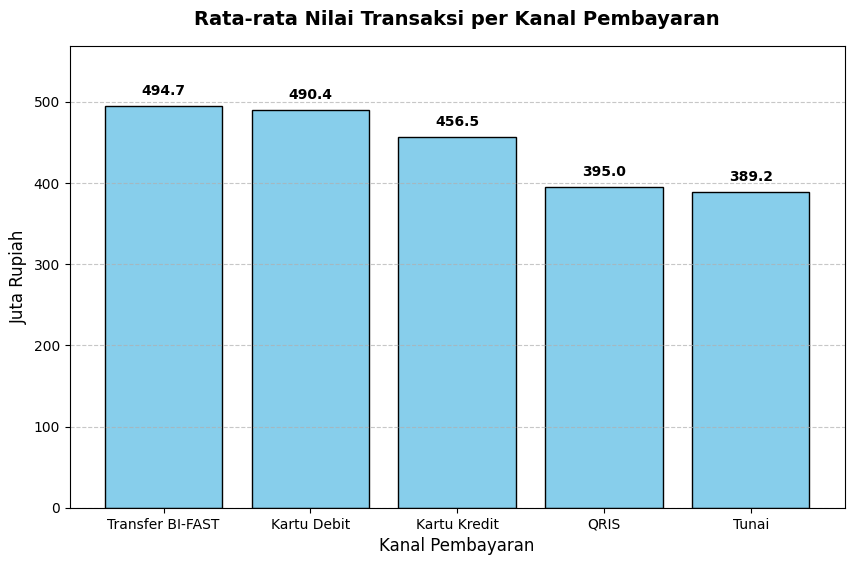

In [ ]:
import matplotlib.pyplot as plt

# 1. Hitung rata-rata Nilai_Transaksi untuk tiap Kanal_Pembayaran
rata_per_kanal = df_transaksi.groupby('Kanal_Pembayaran')['Nilai_Transaksi'].mean()

# 2. Urutkan dari rata-rata terbesar ke terkecil
rata_per_kanal = rata_per_kanal.sort_values(ascending=False)

# 3. Ubah nilai ke satuan Juta Rupiah (dibagi 1.000.000)
rata_per_kanal_juta = rata_per_kanal / 1000000

# 4. Buat diagram batang vertikal memakai matplotlib
plt.figure(figsize=(10, 6))
batang = plt.bar(rata_per_kanal_juta.index, rata_per_kanal_juta.values, color='skyblue', edgecolor='black')

# 5. Beri judul, label sumbu Y, dan tampilkan angka di atas tiap batang
plt.title('Rata-rata Nilai Transaksi per Kanal Pembayaran', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Juta Rupiah', fontsize=12)
plt.xlabel('Kanal Pembayaran', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Menambahkan label angka di atas setiap batang
for btg in batang:
    tinggi = btg.get_height()
    plt.text(
        btg.get_x() + btg.get_width()/2.,
        tinggi + 10,  # memberi sedikit jarak di atas batang
        f'{tinggi:.1f}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

# Mengatur batas sumbu Y agar teks di atas batang tertinggi tidak terpotong
plt.ylim(0, max(rata_per_kanal_juta.values) * 1.15)

# 6. Simpan gambar ke file bernama grafik_1_kanal.png dengan dpi 150
plt.savefig('grafik_1_kanal.png', dpi=150, bbox_inches='tight')

# 7. Tampilkan grafiknya di layar
plt.show()

Sheets 2

=== MATRIKS KORELASI ===
                             Usia  Frekuensi_Gunakan_QRIS  Kepuasan_Layanan_QRIS  Persepsi_Keamanan_Transaksi  Pengetahuan_BI_FAST  Niat_Menggunakan_Lagi  Loyalitas
Usia                         1.00                    0.07                   0.05                        -0.15                -0.11                   0.12       0.03
Frekuensi_Gunakan_QRIS       0.07                    1.00                  -0.09                         0.02                 0.04                  -0.07       0.02
Kepuasan_Layanan_QRIS        0.05                   -0.09                   1.00                         0.01                 0.09                   0.13      -0.09
Persepsi_Keamanan_Transaksi -0.15                    0.02                   0.01                         1.00                 0.03                   0.05       0.22
Pengetahuan_BI_FAST         -0.11                    0.04                   0.09                         0.03                 1.00                  -0

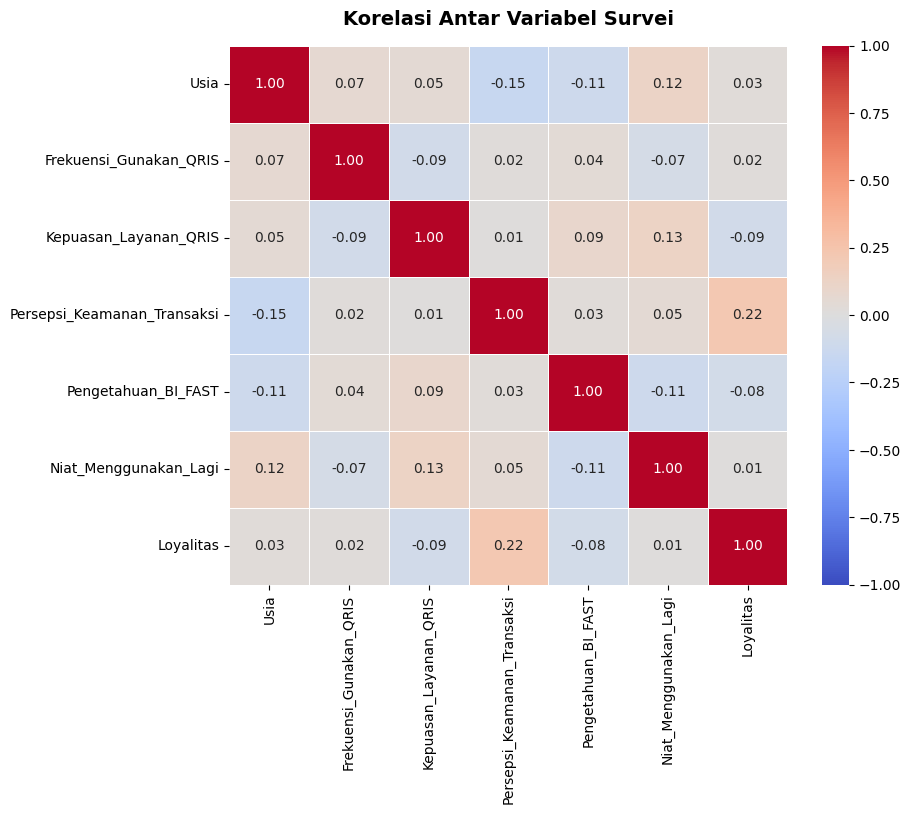

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Ambil hanya 7 kolom angka yang ditentukan dari df_survei
kolom_analisis = [
    'Usia',
    'Frekuensi_Gunakan_QRIS',
    'Kepuasan_Layanan_QRIS',
    'Persepsi_Keamanan_Transaksi',
    'Pengetahuan_BI_FAST',
    'Niat_Menggunakan_Lagi',
    'Loyalitas'
]
df_analisis = df_survei[kolom_analisis]

# 2. Hitung matriks korelasi (Pearson) dan bulatkan 2 angka di belakang koma
korelasi_survei = df_analisis.corr().round(2)

# 3. Tampilkan hasil korelasi_survei secara tekstual dengan to_string()
print("=== MATRIKS KORELASI ===")
print(korelasi_survei.to_string())
print()

# 4. Buat heatmap memakai seaborn
plt.figure(figsize=(9, 7))

sns.heatmap(
    korelasi_survei,
    annot=True,              # Tampilkan angka di dalam kotak
    fmt=".2f",               # Format desimal angka di dalam kotak
    vmin=-1,                 # Skala minimum korelasi
    vmax=1,                  # Skala maksimum korelasi
    cmap='coolwarm',         # Peta warna coolwarm
    linewidths=0.5,          # Memberi garis pembatas antar kotak
    linecolor='white'
)

# 5. Beri judul grafik
plt.title('Korelasi Antar Variabel Survei', fontsize=14, fontweight='bold', pad=15)

# 6. Simpan gambar ke file grafik_3_korelasi.png
plt.savefig('grafik_3_korelasi.png', dpi=150, bbox_inches='tight')

# 7. Tampilkan grafiknya di layar
plt.show()

Sheet 3

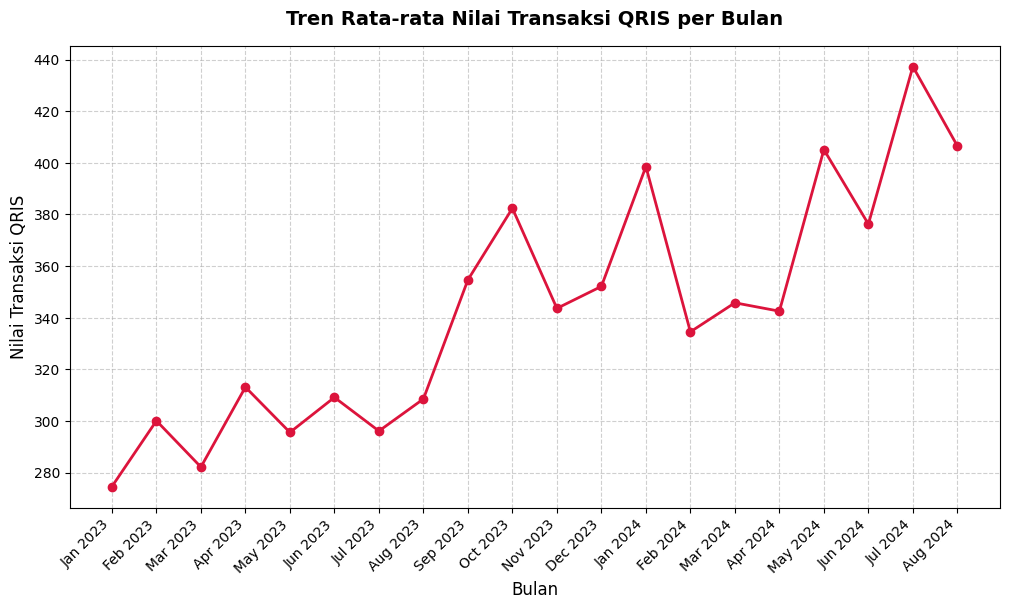

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Hitung rata-rata Nilai Transaksi QRIS untuk tiap Bulan (semua provinsi digabung)
rata_per_bulan = df_makro.groupby('Bulan')['Nilai Transaksi QRIS'].mean()

# Ubah indeks (yang tadinya teks) menjadi tipe datetime agar bisa diurutkan secara kronologis dengan benar
rata_per_bulan.index = pd.to_datetime(rata_per_bulan.index, format='%b %Y')

# 2. Pastikan urutan bulan berurutan dari paling awal ke paling akhir
rata_per_bulan = rata_per_bulan.sort_index()

# Konversi indeks datetime ke format teks 'MMM YYYY' kembali agar terlihat cantik di grafik
bulan_teks = rata_per_bulan.index.strftime('%b %Y')

# 3. Buat diagram garis memakai matplotlib dengan titik penanda (marker)
plt.figure(figsize=(12, 6))
plt.plot(bulan_teks, rata_per_bulan.values, marker='o', color='crimson', linewidth=2, label='Rata-rata Nilai Transaksi')

# 4. Beri judul, label sumbu X, dan label sumbu Y
plt.title('Tren Rata-rata Nilai Transaksi QRIS per Bulan', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Bulan', fontsize=12)
plt.ylabel('Nilai Transaksi QRIS', fontsize=12)

# 5. Putar tulisan sumbu X sebesar 45 derajat dan tambahkan garis bantu (grid)
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.6)

# 6. Simpan gambar ke file bernama grafik_2_tren.png dengan dpi 150
plt.savefig('grafik_2_tren.png', dpi=150, bbox_inches='tight')

# 7. Tampilkan grafiknya di layar
plt.show()

## Regresi Sederhana — Sheet Makro

Koefisien Regresi (Slope) : 0.6342
Intercept Regresi         : 8.0728
R-Square (R-Kuadrat)      : 0.9238
Korelasi (Pearson r)      : 0.9612


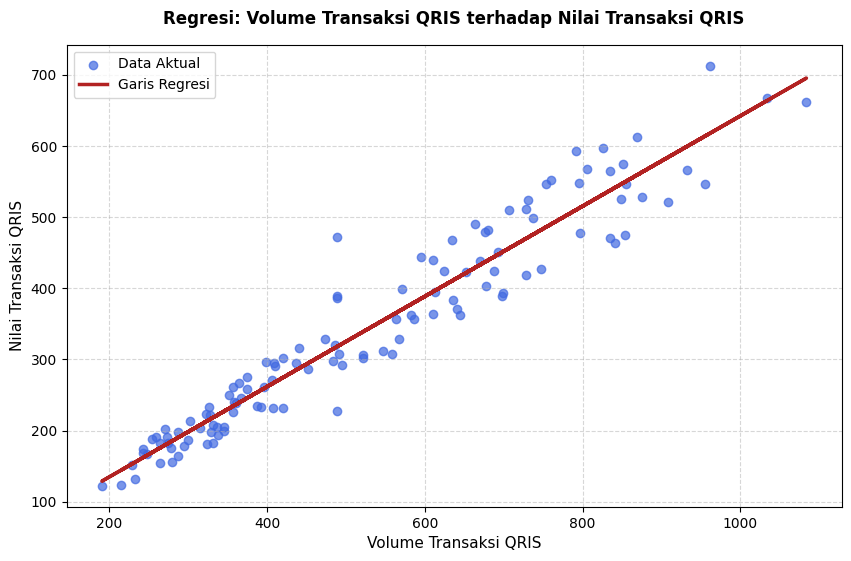

In [ ]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# 1. Siapkan X (harus 2D) dan y
X = df_makro[['Volume Transaksi QRIS']]
y = df_makro['Nilai Transaksi QRIS']

# 2. Buat model LinearRegression dan latih dengan seluruh data
model = LinearRegression()
model.fit(X, y)

# 3. Hitung dan simpan koefisien, intercept, dan R-squared
koefisien_regresi = model.coef_[0]
intercept_regresi = model.intercept_
r_kuadrat = model.score(X, y)

# 4. Hitung korelasi antara kedua kolom
korelasi_volume_nilai = df_makro['Volume Transaksi QRIS'].corr(df_makro['Nilai Transaksi QRIS'])

# 5. Tampilkan keempat nilai dengan print (dibulatkan 4 angka di belakang koma)
print(f"Koefisien Regresi (Slope) : {koefisien_regresi:.4f}")
print(f"Intercept Regresi         : {intercept_regresi:.4f}")
print(f"R-Square (R-Kuadrat)      : {r_kuadrat:.4f}")
print(f"Korelasi (Pearson r)      : {korelasi_volume_nilai:.4f}")

# 6. Buat diagram sebar (scatter) dan gambar garis regresinya
plt.figure(figsize=(10, 6))
plt.scatter(df_makro['Volume Transaksi QRIS'], df_makro['Nilai Transaksi QRIS'], color='royalblue', alpha=0.7, label='Data Aktual')

# Prediksi nilai untuk menggambar garis regresi
y_prediksi = model.predict(X)
plt.plot(df_makro['Volume Transaksi QRIS'], y_prediksi, color='firebrick', linewidth=2.5, label='Garis Regresi')

# 7. Beri judul, label, dan legenda
plt.title('Regresi: Volume Transaksi QRIS terhadap Nilai Transaksi QRIS', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Volume Transaksi QRIS', fontsize=11)
plt.ylabel('Nilai Transaksi QRIS', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

# 8. Simpan gambar ke file grafik_4_regresi.png dengan dpi 150
plt.savefig('grafik_4_regresi.png', dpi=150, bbox_inches='tight')

# 9. Tampilkan grafik
plt.show()

## **Buat Report di MS Word**

5a. Kerangka + tabel + gambar visualisasi

In [ ]:
!pip install -q python-docx

import docx
from docx.shared import Inches, Pt
from google.colab import files

# 1. Inisialisasi dokumen baru
doc = docx.Document()

# Mengatur Judul Utama
judul = doc.add_paragraph()
run_judul = judul.add_run("Laporan Analisis Data Latihan Bank Indonesia")
run_judul.font.size = Pt(18)
run_judul.font.bold = True
judul.alignment = 1 # Center

# Fungsi bantu untuk memformat angka gaya Indonesia
def format_indonesia(angka, desimal=2):
    try:
        # Jika nilai kosong atau NaN
        if pd.isna(angka):
            return "-"

        # Ambil nilai absolut dan jadikan string terformat dengan titik
        fmt_str = f"{angka:,.{desimal}f}"
        # Tukar pemisah ribuan koma (,) menjadi titik (.) dan desimal titik (.) menjadi koma (,)
        parts = fmt_str.split('.')
        # Ganti koma di bagian ribuan dengan titik
        bagian_depan = parts[0].replace(',', '.')
        if len(parts) > 1:
            return bagian_depan + ',' + parts[1]
        return bagian_depan
    except:
        return str(angka)

# 2. Heading Level 1: A. Statistik Deskriptif
h1_stat = doc.add_paragraph()
run_h1 = h1_stat.add_run("A. Statistik Deskriptif")
run_h1.font.size = Pt(14)
run_h1.font.bold = True

# --- A.1 Data Transaksi ---
h2_t1 = doc.add_paragraph()
run_h2_t1 = h2_t1.add_run("A.1 Data Transaksi")
run_h2_t1.font.size = Pt(12)
run_h2_t1.font.bold = True

# Buat Tabel Transaksi (ringkasan_transaksi: 0 desimal)
trans_cols = list(ringkasan_transaksi.columns)
tabel_trans = doc.add_table(rows=1 + len(ringkasan_transaksi), cols=1 + len(trans_cols))
tabel_trans.style = 'Table Grid'

# Header tabel
h_cells = tabel_trans.rows[0].cells
h_cells[0].text = "Statistik"
h_cells[0].paragraphs[0].runs[0].font.size = Pt(8)
h_cells[0].paragraphs[0].runs[0].font.bold = True
for i, col_name in enumerate(trans_cols):
    h_cells[i+1].text = str(col_name)
    h_cells[i+1].paragraphs[0].runs[0].font.size = Pt(8)
    h_cells[i+1].paragraphs[0].runs[0].font.bold = True

# Isi data tabel
for r_idx, indeks_baris in enumerate(ringkasan_transaksi.index):
    row_cells = tabel_trans.rows[r_idx + 1].cells
    row_cells[0].text = str(indeks_baris)
    row_cells[0].paragraphs[0].runs[0].font.size = Pt(8)
    for c_idx, col_name in enumerate(trans_cols):
        nilai_asli = ringkasan_transaksi.at[indeks_baris, col_name]
        row_cells[c_idx + 1].text = format_indonesia(nilai_asli, desimal=0)
        row_cells[c_idx + 1].paragraphs[0].runs[0].font.size = Pt(8)

doc.add_paragraph() # Paragraf kosong setelah tabel

# --- A.2 Data Survei Persepsi ---
h2_t2 = doc.add_paragraph()
run_h2_t2 = h2_t2.add_run("A.2 Data Survei Persepsi")
run_h2_t2.font.size = Pt(12)
run_h2_t2.font.bold = True

# Buat Tabel Survei (ringkasan_survei: 2 desimal)
survei_cols = list(ringkasan_survei.columns)
tabel_survei = doc.add_table(rows=1 + len(ringkasan_survei), cols=1 + len(survei_cols))
tabel_survei.style = 'Table Grid'

# Header tabel
h_cells = tabel_survei.rows[0].cells
h_cells[0].text = "Statistik"
h_cells[0].paragraphs[0].runs[0].font.size = Pt(8)
h_cells[0].paragraphs[0].runs[0].font.bold = True
for i, col_name in enumerate(survei_cols):
    h_cells[i+1].text = str(col_name)
    h_cells[i+1].paragraphs[0].runs[0].font.size = Pt(8)
    h_cells[i+1].paragraphs[0].runs[0].font.bold = True

# Isi data tabel
for r_idx, indeks_baris in enumerate(ringkasan_survei.index):
    row_cells = tabel_survei.rows[r_idx + 1].cells
    row_cells[0].text = str(indeks_baris)
    row_cells[0].paragraphs[0].runs[0].font.size = Pt(8)
    for c_idx, col_name in enumerate(survei_cols):
        nilai_asli = ringkasan_survei.at[indeks_baris, col_name]
        # Tampilkan count tanpa desimal, lainnya pakai 2 desimal
        des = 0 if indeks_baris == "count" else 2
        row_cells[c_idx + 1].text = format_indonesia(nilai_asli, desimal=des)
        row_cells[c_idx + 1].paragraphs[0].runs[0].font.size = Pt(8)

doc.add_paragraph() # Paragraf kosong setelah tabel

# --- A.3 Data Makro Inklusi Keuangan ---
h2_t3 = doc.add_paragraph()
run_h2_t3 = h2_t3.add_run("A.3 Data Makro Inklusi Keuangan")
run_h2_t3.font.size = Pt(12)
run_h2_t3.font.bold = True

# Buat Tabel Makro (ringkasan_makro: 2 desimal)
makro_cols = list(ringkasan_makro.columns)
tabel_makro = doc.add_table(rows=1 + len(ringkasan_makro), cols=1 + len(makro_cols))
tabel_makro.style = 'Table Grid'

# Header tabel
h_cells = tabel_makro.rows[0].cells
h_cells[0].text = "Statistik"
h_cells[0].paragraphs[0].runs[0].font.size = Pt(8)
h_cells[0].paragraphs[0].runs[0].font.bold = True
for i, col_name in enumerate(makro_cols):
    h_cells[i+1].text = str(col_name)
    h_cells[i+1].paragraphs[0].runs[0].font.size = Pt(8)
    h_cells[i+1].paragraphs[0].runs[0].font.bold = True

# Isi data tabel
for r_idx, indeks_baris in enumerate(ringkasan_makro.index):
    row_cells = tabel_makro.rows[r_idx + 1].cells
    row_cells[0].text = str(indeks_baris)
    row_cells[0].paragraphs[0].runs[0].font.size = Pt(8)
    for c_idx, col_name in enumerate(makro_cols):
        nilai_asli = ringkasan_makro.at[indeks_baris, col_name]
        # Tampilkan count tanpa desimal, lainnya pakai 2 desimal
        des = 0 if indeks_baris == "count" else 2
        row_cells[c_idx + 1].text = format_indonesia(nilai_asli, desimal=des)
        row_cells[c_idx + 1].paragraphs[0].runs[0].font.size = Pt(8)

doc.add_paragraph() # Paragraf kosong setelah tabel

# 3. Heading Level 1: B. Visualisasi
h1_vis = doc.add_paragraph()
run_vis = h1_vis.add_run("B. Visualisasi")
run_vis.font.size = Pt(14)
run_vis.font.bold = True

# Daftar Gambar beserta keterangannya
gambar_list = [
    ("grafik_1_kanal.png", "Gambar 1. Rata-rata nilai transaksi per kanal pembayaran."),
    ("grafik_2_tren.png", "Gambar 2. Tren rata-rata nilai transaksi QRIS per bulan."),
    ("grafik_3_korelasi.png", "Gambar 3. Korelasi antar variabel survei."),
    ("grafik_4_regresi.png", "Gambar 4. Regresi volume transaksi QRIS terhadap nilai transaksi QRIS.")
]

for file_gambar, teks_keterangan in gambar_list:
    try:
        # Masukkan gambar dengan lebar 5.5 inci
        doc.add_picture(file_gambar, width=Inches(5.5))
        # Tambahkan teks keterangan gambar di bawahnya
        p_ket = doc.add_paragraph()
        run_ket = p_ket.add_run(teks_keterangan)
        run_ket.font.size = Pt(10)
        run_ket.font.italic = True
        doc.add_paragraph() # Beri spasi kosong
    except Exception as e:
        print(f"Gagal memasukkan {file_gambar}: {e}")

# 4. Simpan dokumen
nama_laporan = "laporan_analisis_bi.docx"
doc.save(nama_laporan)
print(f"Laporan berhasil dibuat dan disimpan sebagai: {nama_laporan}")

# 5. Unduh file dokumen
files.download(nama_laporan)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 1.8 MB/s eta 0:00:00
Laporan berhasil dibuat dan disimpan sebagai: laporan_analisis_bi.docx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

5b. Tambah penjelasan ke dalam laporan

In [ ]:
import docx
from docx.shared import Inches, Pt
from google.colab import files
import pandas as pd

# 1. Inisialisasi dokumen baru
doc = docx.Document()

# Mengatur Judul Utama
judul = doc.add_paragraph()
run_judul = judul.add_run("Laporan Analisis Data Latihan Bank Indonesia")
run_judul.font.size = Pt(18)
run_judul.font.bold = True
judul.alignment = 1 # Center

# --- PENDAHULUAN ---
h1_pend = doc.add_paragraph()
run_h1_pend = h1_pend.add_run("Pendahuluan")
run_h1_pend.font.size = Pt(14)
run_h1_pend.font.bold = True

p_pend = doc.add_paragraph()
run_p_pend = p_pend.add_run("Laporan ini merangkum hasil analisis tiga kumpulan data latihan yang telah dibersihkan: data transaksi (194 baris, periode Januari sampai Desember 2024), data survei persepsi responden (146 baris), dan data makro inklusi keuangan di enam provinsi (120 baris, periode Januari 2023 sampai Agustus 2024). Analisis mencakup statistik deskriptif, visualisasi, korelasi, dan regresi linear sederhana.")
run_p_pend.font.size = Pt(11)

# Fungsi bantu untuk memformat angka gaya Indonesia
def format_indonesia(angka, desimal=2):
    try:
        if pd.isna(angka):
            return "-"
        fmt_str = f"{angka:,.{desimal}f}"
        parts = fmt_str.split('.')
        bagian_depan = parts[0].replace(',', '.')
        if len(parts) > 1:
            return bagian_depan + ',' + parts[1]
        return bagian_depan
    except:
        return str(angka)

# --- A. STATISTIK DESKRIPTIF ---
h1_stat = doc.add_paragraph()
run_h1 = h1_stat.add_run("A. Statistik Deskriptif")
run_h1.font.size = Pt(14)
run_h1.font.bold = True

# A.1 Data Transaksi
h2_t1 = doc.add_paragraph()
run_h2_t1 = h2_t1.add_run("A.1 Data Transaksi")
run_h2_t1.font.size = Pt(12)
run_h2_t1.font.bold = True

tabel_trans = doc.add_table(rows=1 + len(ringkasan_transaksi), cols=1 + len(ringkasan_transaksi.columns))
tabel_trans.style = 'Table Grid'
h_cells = tabel_trans.rows[0].cells
h_cells[0].text = "Statistik"
h_cells[0].paragraphs[0].runs[0].font.size = Pt(8)
h_cells[0].paragraphs[0].runs[0].font.bold = True
for i, col_name in enumerate(ringkasan_transaksi.columns):
    h_cells[i+1].text = str(col_name)
    h_cells[i+1].paragraphs[0].runs[0].font.size = Pt(8)
    h_cells[i+1].paragraphs[0].runs[0].font.bold = True

for r_idx, indeks_baris in enumerate(ringkasan_transaksi.index):
    row_cells = tabel_trans.rows[r_idx + 1].cells
    row_cells[0].text = str(indeks_baris)
    row_cells[0].paragraphs[0].runs[0].font.size = Pt(8)
    for c_idx, col_name in enumerate(ringkasan_transaksi.columns):
        nilai_asli = ringkasan_transaksi.at[indeks_baris, col_name]
        row_cells[c_idx + 1].text = format_indonesia(nilai_asli, desimal=0)
        row_cells[c_idx + 1].paragraphs[0].runs[0].font.size = Pt(8)

doc.add_paragraph()

# A.2 Data Survei Persepsi
h2_t2 = doc.add_paragraph()
run_h2_t2 = h2_t2.add_run("A.2 Data Survei Persepsi")
run_h2_t2.font.size = Pt(12)
run_h2_t2.font.bold = True

tabel_survei = doc.add_table(rows=1 + len(ringkasan_survei), cols=1 + len(ringkasan_survei.columns))
tabel_survei.style = 'Table Grid'
h_cells = tabel_survei.rows[0].cells
h_cells[0].text = "Statistik"
h_cells[0].paragraphs[0].runs[0].font.size = Pt(8)
h_cells[0].paragraphs[0].runs[0].font.bold = True
for i, col_name in enumerate(ringkasan_survei.columns):
    h_cells[i+1].text = str(col_name)
    h_cells[i+1].paragraphs[0].runs[0].font.size = Pt(8)
    h_cells[i+1].paragraphs[0].runs[0].font.bold = True

for r_idx, indeks_baris in enumerate(ringkasan_survei.index):
    row_cells = tabel_survei.rows[r_idx + 1].cells
    row_cells[0].text = str(indeks_baris)
    row_cells[0].paragraphs[0].runs[0].font.size = Pt(8)
    for c_idx, col_name in enumerate(ringkasan_survei.columns):
        nilai_asli = ringkasan_survei.at[indeks_baris, col_name]
        des = 0 if indeks_baris == "count" else 2
        row_cells[c_idx + 1].text = format_indonesia(nilai_asli, desimal=des)
        row_cells[c_idx + 1].paragraphs[0].runs[0].font.size = Pt(8)

doc.add_paragraph()

# A.3 Data Makro Inklusi Keuangan
h2_t3 = doc.add_paragraph()
run_h2_t3 = h2_t3.add_run("A.3 Data Makro Inklusi Keuangan")
run_h2_t3.font.size = Pt(12)
run_h2_t3.font.bold = True

tabel_makro = doc.add_table(rows=1 + len(ringkasan_makro), cols=1 + len(ringkasan_makro.columns))
tabel_makro.style = 'Table Grid'
h_cells = tabel_makro.rows[0].cells
h_cells[0].text = "Statistik"
h_cells[0].paragraphs[0].runs[0].font.size = Pt(8)
h_cells[0].paragraphs[0].runs[0].font.bold = True
for i, col_name in enumerate(ringkasan_makro.columns):
    h_cells[i+1].text = str(col_name)
    h_cells[i+1].paragraphs[0].runs[0].font.size = Pt(8)
    h_cells[i+1].paragraphs[0].runs[0].font.bold = True

for r_idx, indeks_baris in enumerate(ringkasan_makro.index):
    row_cells = tabel_makro.rows[r_idx + 1].cells
    row_cells[0].text = str(indeks_baris)
    row_cells[0].paragraphs[0].runs[0].font.size = Pt(8)
    for c_idx, col_name in enumerate(ringkasan_makro.columns):
        nilai_asli = ringkasan_makro.at[indeks_baris, col_name]
        des = 0 if indeks_baris == "count" else 2
        row_cells[c_idx + 1].text = format_indonesia(nilai_asli, desimal=des)
        row_cells[c_idx + 1].paragraphs[0].runs[0].font.size = Pt(8)

doc.add_paragraph()

# --- B. VISUALISASI ---
h1_vis = doc.add_paragraph()
run_vis = h1_vis.add_run("B. Visualisasi")
run_vis.font.size = Pt(14)
run_vis.font.bold = True

gambar_list = [
    ("grafik_1_kanal.png", "Gambar 1. Rata-rata nilai transaksi per kanal pembayaran."),
    ("grafik_2_tren.png", "Gambar 2. Tren rata-rata nilai transaksi QRIS per bulan."),
    ("grafik_3_korelasi.png", "Gambar 3. Korelasi antar variabel survei."),
    ("grafik_4_regresi.png", "Gambar 4. Regresi volume transaksi QRIS terhadap nilai transaksi QRIS.")
]

for file_gambar, teks_keterangan in gambar_list:
    try:
        doc.add_picture(file_gambar, width=Inches(5.5))
        p_ket = doc.add_paragraph()
        run_ket = p_ket.add_run(teks_keterangan)
        run_ket.font.size = Pt(10)
        run_ket.font.italic = True
        doc.add_paragraph()
    except Exception as e:
        print(f"Gagal memasukkan {file_gambar}: {e}")

# --- C. CATATAN DATA ---
h1_cat = doc.add_paragraph()
run_h1_cat = h1_cat.add_run("C. Catatan Data")
run_h1_cat.font.size = Pt(14)
run_h1_cat.font.bold = True

catatan_paragraphs = [
    "Berkas latihan semula berisi 200 baris data transaksi, 150 baris data survei, dan 120 baris data makro. Setelah pembersihan, jumlah baris menjadi 194, 146, dan 120.",
    "Aturan pembersihan yang digunakan: tanggal bergaris miring dibaca sebagai hari/bulan/tahun; usia dianggap wajar pada rentang 17 sampai 100 tahun; skala frekuensi penggunaan 1 sampai 7 dan skor survei lainnya 1 sampai 5; nilai negatif dan nilai ekstrem dikosongkan lalu diisi dengan median; sel teks yang kosong diisi dengan modus; data makro yang kosong diisi dengan median per provinsi.",
    "Keputusan pengisian median memengaruhi hasil. Pada kolom Nilai_Transaksi, nilai 419.292.000 muncul 10 kali karena berasal dari pengisian median, sehingga nilai tengah (50%) kolom tersebut sama dengan angka ini. Rata-rata dan sebaran kolom tersebut perlu dibaca dengan kehati-hatian."
]

for paragraf_teks in catatan_paragraphs:
    p_cat = doc.add_paragraph()
    run_p_cat = p_cat.add_run(paragraf_teks)
    run_p_cat.font.size = Pt(11)

# --- D. TEMUAN DAN KESIMPULAN ---
h1_kes = doc.add_paragraph()
run_h1_kes = h1_kes.add_run("D. Temuan dan Kesimpulan")
run_h1_kes.font.size = Pt(14)
run_h1_kes.font.bold = True

temuan_list = [
    ("D.1 Kanal Pembayaran", "Rata-rata nilai transaksi tertinggi terdapat pada kanal Transfer BI-FAST (494,75 juta rupiah), disusul Kartu Debit (490,39 juta) and Kartu Kredit (456,53 juta). Rata-rata terendah terdapat pada Tunai (389,20 juta) dan QRIS (384,35 juta). Perlu dicatat bahwa QRIS adalah kanal dengan jumlah transaksi terbanyak (67 dari 194 transaksi)."),
    ("D.2 Tren Transaksi QRIS", "Rata-rata nilai transaksi QRIS per bulan cenderung naik, dari 274,62 pada Januari 2023 menjadi 406,55 pada Agustus 2024, dengan puncak 437,30 pada Juli 2024. Kenaikan tersebut tidak mulus karena terdapat naik-turun antarbulan."),
    ("D.3 Korelasi Variabel Survei", "Rata-rata skor survei berada di sekitar tengah skala, yaitu 2,85 sampai 3,16 pada skala 1 sampai 5 (frekuensi penggunaan QRIS rata-rata 3,96 pada skala 1 sampai 7). Seluruh korelasi antar variabel survei tergolong lemah. Korelasi tertinggi adalah Persepsi Keamanan Transaksi dengan Loyalitas (0,22) dan korelasi terendah adalah Usia dengan Persepsi Keamanan Transaksi (-0,15). Dengan demikian tidak ditemukan hubungan yang kuat antar variabel survei."),
    ("D.4 Regresi Data Makro", "Pada data makro, regresi linear sederhana menunjukkan bahwa setiap kenaikan 1 poin Volume Transaksi QRIS diikuti kenaikan sekitar 0,64 poin Nilai Transaksi QRIS (koefisien 0,6355). Nilai R-kuadrat sebesar 0,9404 dan korelasi sebesar 0,9698 menunjukkan hubungan yang sangat kuat. Pada volume besar (di atas sekitar 800), titik data lebih menyebar dari garis sehingga perkiraan pada rentang tersebut kurang presisi. Hubungan ini menunjukkan keterkaitan, bukan bukti sebab-akibat."),
    ("D.5 Kesimpulan", "Secara ringkas: (1) nilai transaksi QRIS cenderung naik sepanjang periode pengamatan; (2) volume dan nilai transaksi QRIS berkaitan sangat kuat; (3) variabel survei tidak saling berhubungan secara kuat; (4) hasil pada data transaksi perlu dibaca dengan memperhatikan pengisian median.")
]

for judul_sub, isi_sub in temuan_list:
    h2_sub = doc.add_paragraph()
    run_h2_sub = h2_sub.add_run(judul_sub)
    run_h2_sub.font.size = Pt(12)
    run_h2_sub.font.bold = True

    p_sub = doc.add_paragraph()
    run_p_sub = p_sub.add_run(isi_sub)
    run_p_sub.font.size = Pt(11)

# 4. Simpan dokumen baru
nama_laporan_lengkap = "laporan_analisis_bi_lengkap.docx"
doc.save(nama_laporan_lengkap)
print(f"Laporan lengkap berhasil dibuat dan disimpan sebagai: {nama_laporan_lengkap}")

# 5. Unduh file dokumen secara otomatis
files.download(nama_laporan_lengkap)

Laporan lengkap berhasil dibuat dan disimpan sebagai: laporan_analisis_bi_lengkap.docx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>